# Exercise 1

## 1) c)

For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

Let X1, X2 be the GPA and IQ respectively.

then for females the salary (in thousands of dollars) is given by  

85 + 10X1 + 0.07X2 + 0.01X1X2

for males the salary (in thousands of dollars) is given by  

50 + 20X1 + 0.07X2 + 0.01X1X2

SO the salary of males is higher than that of females if  

X1 > 3.5

---

## 2)

X1 = 4 , X2 = 110 then the salary of a female from the model is $137.1k

---

## 3)

False.From the above question, we are expected to use the given values wothout any transformation to get the value fo the salary, this implies that the data used is not scaled before the coefficients are estimated. Therefore the coefficents cannot be directly used as the measure of importance of the predictor.


# Exercise 2

In [18]:
#Using stats model instead of the R functions which is asked in the question
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np


In [7]:
# read data
auto = pd.read_csv(
    "https://raw.githubusercontent.com/SanthoshBV07/Accio-Alpha-WIDS/main/Week2/data/Auto.csv"
)
auto.head(5)


,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,object
weight,int64
acceleration,float64
year,int64
origin,int64
name,object


In [8]:
auto.dtypes
#stats model requires numeric values to operate upon, so converting types while handling nulls

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,object
weight,int64
acceleration,float64
year,int64
origin,int64
name,object


In [15]:
auto['horsepower'] = pd.to_numeric(auto['horsepower'], errors='coerce')

# drop rows with missing values
auto = auto.dropna(subset=['mpg', 'horsepower'])
y = auto['mpg']
X = auto['horsepower']

# add intercept
X_const = sm.add_constant(X)

# fit model
model = sm.OLS(y, X_const)
results = model.fit()

# print summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Wed, 24 Dec 2025   Prob (F-statistic):           7.03e-81
Time:                        16:31:41   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.0

In [19]:
x_new = np.array([[1, 98]])
prediction = results.get_prediction(x_new)
summary = prediction.summary_frame(alpha=0.05)

print(summary)

        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  24.467077  0.251262      23.973079      24.961075     14.809396   

   obs_ci_upper  
0     34.124758  


The summary statistics, especially the R2 value of 0.606 indicate that SLR  model somewhat captures the underlyign relationship. The Skew and Kurtosis of the errors also insdicate near normal distribution. From the model the predicted Mileage for horsepower of 98 is 24.4 mpg and the original value lies within the interval 14.8, 34.12 with 95% probability.

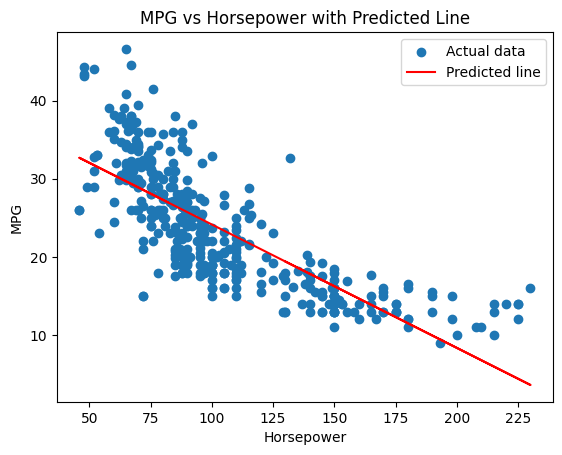

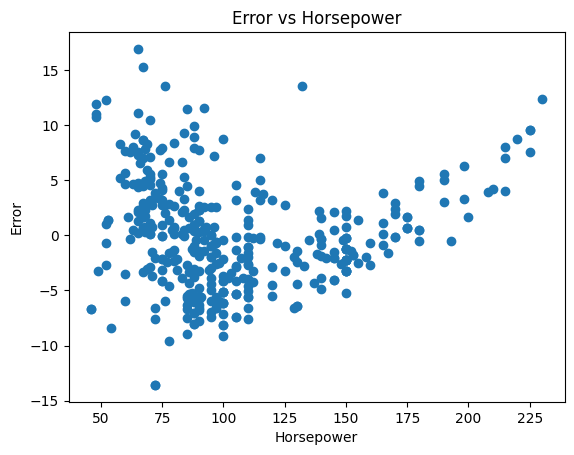

In [20]:

y_pred = results.predict(X_const)
error = y - y_pred

# Plot actual data
plt.scatter(X, y, label='Actual data')
plt.plot(X, y_pred, color='red', label='Predicted line')

# Labels and title
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('MPG vs Horsepower with Predicted Line')
plt.legend()

plt.show()
plt.scatter(X, error)
plt.xlabel('Horsepower')
plt.ylabel('Error')
plt.title('Error vs Horsepower')
plt.show()

From the error plots and the plots of the predicted and response variables we can conclude that the model has failed to capture the underlying non linearity in the data. This shows up as a parabolic error plot. The model could be improved by adding further polynomial features or using non parametric models like random forest.

#Exercise 3

In [30]:
import pandas as pd

# Load the data from GitHub raw URLs
cad_url = "https://raw.githubusercontent.com/SanthoshBV07/Accio-Alpha-WIDS/main/Week2/data/inputData_AUDCAD_20120426.csv"
usd_url = "https://raw.githubusercontent.com/SanthoshBV07/Accio-Alpha-WIDS/main/Week2/data/inputData_AUDUSD_20120426.csv"

cad_df = pd.read_csv(cad_url)
usd_df = pd.read_csv(usd_url)

# Show first 5 rows of each
print("CAD DataFrame — first 5 rows:")
print(cad_df.head())
print(cad_df.shape)

print("\nUSD DataFrame — first 5 rows:")
print(usd_df.head())
print(usd_df.shape)

# Make sure the date column is named the same
# If needed, convert to datetime
cad_df["Date"] = pd.to_datetime(cad_df["Date"], format='%Y%m%d')
usd_df["Date"] = pd.to_datetime(usd_df["Date"], format='%Y%m%d')

# Inner join on Date (Using USD/AUD for inner join as it has lower number fo entries)
joined_df = usd_df.merge(cad_df, on="Date", how="inner", suffixes=("_usd", "_cad"))

# Rename the close columns

joined_df.rename(columns={
    "Close_usd": "Close_usd",
    "Close_cad": "Close_cad"
}, inplace=True)
#generate USD/CAD column
joined_df['usd.cad']= joined_df['Close_usd']/joined_df['Close_cad']


# Show the joined result
print("\nJoined DataFrame — first 5 rows:")
print(joined_df.head())

# Check for nulls
null_count_before = joined_df.isnull().sum().sum()
print(f"\nTotal null values before removal: {null_count_before}")

# Remove nulls
joined_df_cleaned = joined_df.dropna()

CAD DataFrame — first 5 rows:
       Date    Close
0  20070723  0.92460
1  20070724  0.91355
2  20070725  0.92035
3  20070726  0.91780
4  20070727  0.90655
(1237, 2)

USD DataFrame — first 5 rows:
       Date     Close
0  20090102  0.711325
1  20090105  0.717450
2  20090106  0.723300
3  20090107  0.712675
4  20090108  0.712250
(862, 2)

Joined DataFrame — first 5 rows:
        Date  Close_usd  Close_cad   usd.cad
0 2009-01-02   0.711325   0.857275  0.829751
1 2009-01-05   0.717450   0.853075  0.841016
2 2009-01-06   0.723300   0.856400  0.844582
3 2009-01-07   0.712675   0.850800  0.837653
4 2009-01-08   0.712250   0.840350  0.847564

Total null values before removal: 0


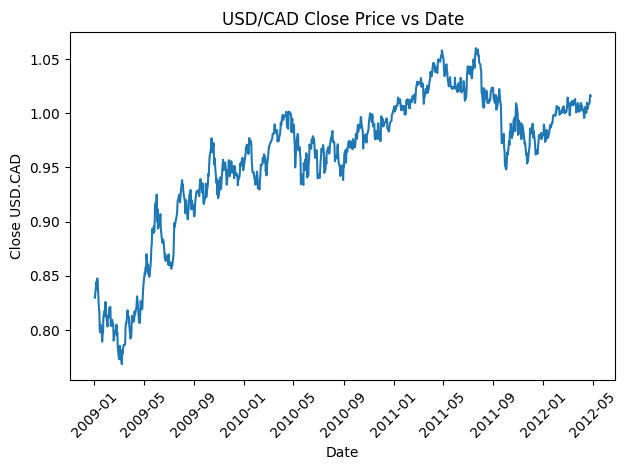

In [31]:
#USD close plot
plt.figure()
plt.plot(joined_df["Date"], joined_df["usd.cad"])
plt.xlabel("Date")
plt.ylabel("Close USD.CAD")
plt.title("USD/CAD Close Price vs Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


From the above graph we can visually confirm that they are not stationary. This is because it shows upward drift . Therefore they resemble random walk more than flat noise. The mean taken at different instants of time is not the same. Therefore in relevance to time series analysis they do not have a clear mean.

In [47]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
joined_df['log_usd.cad'] = np.log(joined_df['usd.cad'])
result = adfuller(joined_df['log_usd.cad'],maxlag=1)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print(f'Lags Used: {result[2]}')

print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value:.4f}')

ADF Statistic: -1.8632
p-value: 0.3496
Lags Used: 1
Critical Values:
   1%: -3.4380
   5%: -2.8649
   10%: -2.5686


The critical value for 90% confidence is -2.568, and the p-value is 0.34 >0.1
so we cannot reject the null hypotheses which implies that the series is not stationary and the mean revrsion model cannot be used for this pair of currencies.

In [36]:
def calculate_half_life(series):
    # y_t - y_{t-1} = alpha + beta * y_{t-1}
    lagged_series = series.shift(1).dropna()
    delta_series = series.diff().dropna()


    x = sm.add_constant(lagged_series.values)
    y = delta_series.values


    model = sm.OLS(y, x)
    results = model.fit()
    beta = results.params[1]
    half_life = -np.log(2) / beta
    return half_life

print(calculate_half_life(joined_df['log_usd.cad']))

94.36967596122362


It takes around 95 days for the prices to return to half of the mean after a spike. This is a very long duration and does not result in prices returning to mean. It usually behaves as a trend and cannot be capitalised for mean reversion strategy by a trader.

#Exercise 4
EWA and EWC are the indexes of Australia and Canada respectively. They are the mostly know example of pairs trading due to the high interdependence in the nature of both countries economy. Therefore mean reversion strategy can be used for the combination of both.

In [40]:
data_url = "https://raw.githubusercontent.com/SanthoshBV07/Accio-Alpha-WIDS/main/Week2/data/inputData_EWA_EWC.csv"
df = pd.read_csv(data_url)
df["Date"] = pd.to_datetime(df["Date"], format='%Y%m%d')
# Show first 5 rows of each
print("EWA, EWC closing prices")
print(df.head())
print(df.shape)

EWA, EWC closing prices
        Date    EWA    EWC
0 2006-04-26  16.10  22.95
1 2006-04-27  15.98  22.78
2 2006-04-28  16.10  22.94
3 2006-05-01  16.31  23.05
4 2006-05-02  16.29  23.32
(1500, 3)


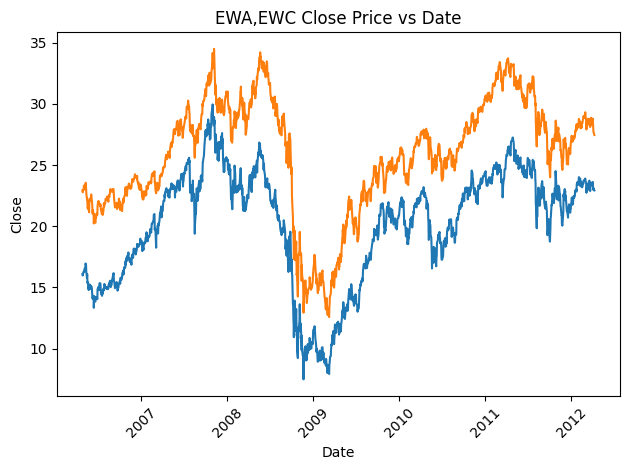

In [41]:
plt.figure()
plt.plot(df["Date"], df["EWA"])
plt.plot(df["Date"], df["EWC"])
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("EWA,EWC Close Price vs Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [42]:
correlation = df['EWA'].corr(df['EWC'])

print(f"Correlation between EWA and EWC: {correlation:.4f}")

Correlation between EWA and EWC: 0.9575


Correlation coefficient of 0.9575 indicates strong positive correlation between the closing prices of EWA and EWC

In [43]:
y = df['EWA']
X = df['EWC']
X = sm.add_constant(X)
model = sm.OLS(y, X)
results = model.fit()
print(f"Hedge Ratio (Coefficient of EWC): {results.params[1]:.4f}")
print(f"Intercept: {results.params[0]:.4f}")

Hedge Ratio (Coefficient of EWC): 0.9527
Intercept: -4.4324


/tmp/ipython-input-348935657.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Hedge Ratio (Coefficient of EWC): {results.params[1]:.4f}")
/tmp/ipython-input-348935657.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Intercept: {results.params[0]:.4f}")


From OLS we get EWA = 0.952 * EWC - 4.432

Hedge ratio is 0.952

In [44]:
df['spread'] = df['EWA'] - (0.9527 * df['EWC'] - 4.4324)
print(df.head())

        Date    EWA    EWC    spread
0 2006-04-26  16.10  22.95 -1.332065
1 2006-04-27  15.98  22.78 -1.290106
2 2006-04-28  16.10  22.94 -1.322538
3 2006-05-01  16.31  23.05 -1.217335
4 2006-05-02  16.29  23.32 -1.494564


In [54]:
result = adfuller(df['spread'],maxlag=1)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print(f'Lags Used: {result[2]}')

print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value:.4f}')
print("Half Life of mean reversion is :",calculate_half_life(df['spread']))
std = df['spread'].std()
mean = df['spread'].mean()
print(f"for z score of 2  : spread is {2*std+mean:.3f} and for -2 it is {-2*std+mean: .3f}")


ADF Statistic: -3.6394
p-value: 0.0051
Lags Used: 1
Critical Values:
   1%: -3.4347
   5%: -2.8635
   10%: -2.5678
Half Life of mean reversion is : 27.95040969110321
for z score of 2  : spread is 2.680 and for -2 it is -2.682


The p value is 0.0051 which is less than 0.05 required for 95% confidence interval, this imples that the spread is stationary and mean reversion strategy can be used to trade in pairs with EWA and EWC. It takes around 28 days to return to half the mean value after a distortion from the mean is found. The spread when calculated as EWA - 0.952 EWC +4.432, when it is greater than 2.680, the z score is greater than 2 and we can enter into long positions of EWA and short positions of EWC with the given hedge ratio. When the z score nears zero we can close our positions. Vice versa can be done when the spread is less than the mean by 2 standard devations at -2.682.